# Apple Stock Prices From 1981 to 2023

## 1. Data Loading and Exploration

In [1]:
import pandas as pd
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

/Users/mariekrammer/anaconda3/lib/python3.10/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df = pd.read_csv('/Users/mariekrammer/Desktop/DI learning/week_4_ML_AI/day_3/Apple Stock Prices (1981 to 2023).csv')


the columns of the dataset are :
- Date: Represents the date of the stock price.
- Open: Represents the opening stock price on that date.
- High: Represents the highest stock price on that date.
- Low: Represents the lowest stock price on that date.
- Close: Represents the closing stock price on that date.
- Adj close: Represents the adjusted closing stock price on that date (taking into account corporate actions such as splits).
- Volume: Represents the number of shares traded on that date.

In [3]:
print(df.head())
print(df.shape)
print(df.columns)
df.info()
df.describe()

         Date      Open      High       Low     Close  Adj Close    Volume
0  02/01/1981  0.154018  0.155134  0.154018  0.154018   0.119849  21660800
1  05/01/1981  0.151228  0.151228  0.150670  0.150670   0.117244  35728000
2  06/01/1981  0.144531  0.144531  0.143973  0.143973   0.112032  45158400
3  07/01/1981  0.138393  0.138393  0.137835  0.137835   0.107256  55686400
4  08/01/1981  0.135603  0.135603  0.135045  0.135045   0.105085  39827200
(10608, 7)
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'], dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10608 entries, 0 to 10607
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       10608 non-null  object 
 1   Open       10608 non-null  float64
 2   High       10608 non-null  float64
 3   Low        10608 non-null  float64
 4   Close      10608 non-null  float64
 5   Adj Close  10608 non-null  float64
 6   Volume     10608 no

,Open,High,Low,Close,Adj Close,Volume
count,10608.000000,10608.000000,10608.000000,10608.000000,10608.000000,1.060800e+04
mean,16.689173,16.879955,16.500822,16.697362,16.027345,3.275098e+08
std,35.450519,35.882848,35.031289,35.473912,35.154878,3.378203e+08
min,0.049665,0.049665,0.049107,0.049107,0.038213,0.000000e+00
25%,0.287946,0.296875,0.282355,0.288923,0.238909,1.213044e+08
50%,0.488839,0.495536,0.480446,0.487701,0.404851,2.145976e+08
75%,16.320893,16.418483,16.151249,16.269554,14.073167,4.066804e+08
max,182.630005,182.940002,179.119995,182.009995,180.959747,7.421641e+09


Are there any duplicates?

In [4]:
print(df[df.duplicated()])

Empty DataFrame
Columns: [Date, Open, High, Low, Close, Adj Close, Volume]
Index: []


No duplicate!

Are there any missing value ? No according to info()

### Feature enginiring

Volatility of the stoke price during the day:

In [5]:
df['range'] = df['High'] - df['Low']

### Outliers

In [6]:
print(df.loc[df['Open']>182])
print(df.loc[df['Close']==182.009995])

             Date        Open        High         Low       Close   Adj Close  \
10340  04/01/2022  182.630005  182.940002  179.119995  179.699997  178.663071   

         Volume     range  
10340  99310400  3.820007  
             Date        Open        High         Low       Close   Adj Close  \
10339  03/01/2022  177.830002  182.880005  177.710007  182.009995  180.959747   

          Volume     range  
10339  104487900  5.169998  


In [7]:
# df_before = df.copy()

# for col in df.columns[1:]:  # skip Date
#     lower = df[col].quantile(0.05)
#     upper = df[col].quantile(0.95)
#     df[col]=df[col].clip(lower,upper)

# for col in df.columns[1:]:
#     print(col, (df_before[col] != df[col]).sum())

### Scaling

## Time series properties

Let's examine the time series properties of the data (e.g., frequency, trends)

In [8]:
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')
df = df.sort_values('Date')
print(df.head())

        Date      Open      High       Low     Close  Adj Close    Volume  \
0 1981-01-02  0.154018  0.155134  0.154018  0.154018   0.119849  21660800   
1 1981-01-05  0.151228  0.151228  0.150670  0.150670   0.117244  35728000   
2 1981-01-06  0.144531  0.144531  0.143973  0.143973   0.112032  45158400   
3 1981-01-07  0.138393  0.138393  0.137835  0.137835   0.107256  55686400   
4 1981-01-08  0.135603  0.135603  0.135045  0.135045   0.105085  39827200   

      range  
0  0.001116  
1  0.000558  
2  0.000558  
3  0.000558  
4  0.000558  


In [9]:
frequency = [0]
for i in range(1,len(df['Date'])):
    frequency.append((df['Date'].iloc[i]-df['Date'].iloc[i-1]).days)
print(frequency)

df['frequency']=frequency
   

[0, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 4, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 4, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 4, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 4, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 4, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 2, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 4, 1, 1, 1, 4, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 4, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 1, 1, 4, 1, 1, 1, 1, 3, 1, 1, 1, 1, 3, 1, 

Visualation of the frequency :

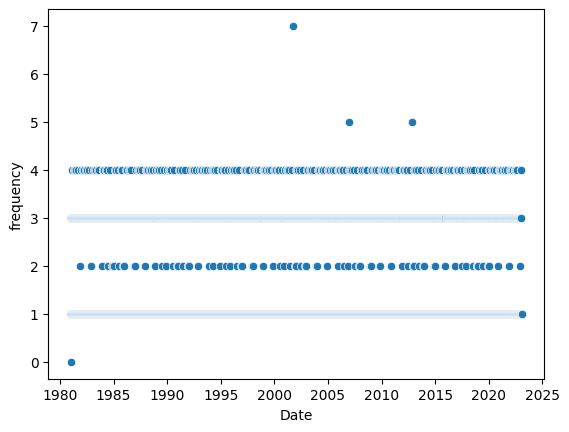

In [10]:
sns.scatterplot(data =df,x='Date',y='frequency')
plt.show()

Visualation of the trends:

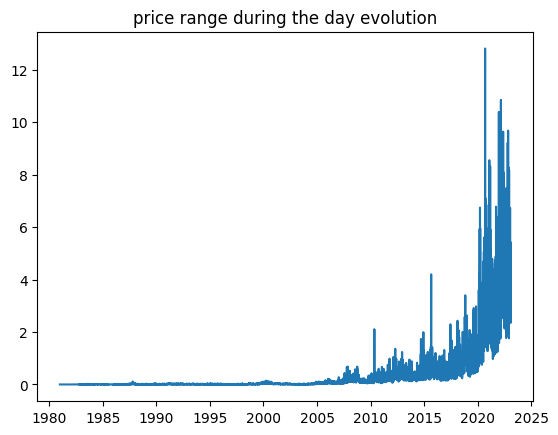

In [11]:
plt.plot(df['Date'], df['range'])
plt.title("price range during the day evolution")
plt.show()

Overall, the fluctuation between the beginning and the end of the day increases.

Price evolution:

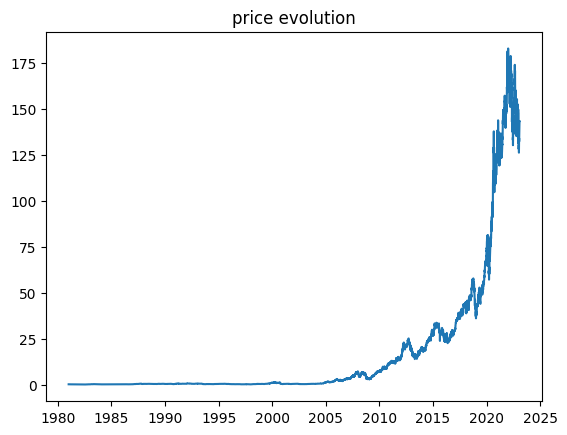

In [12]:
plt.plot(df['Date'], df['Open'])
plt.title("price evolution")
plt.show()

Overwall, the price of the stoke increases

### Data Visualization

we will plot closing prices and traded volume over time.

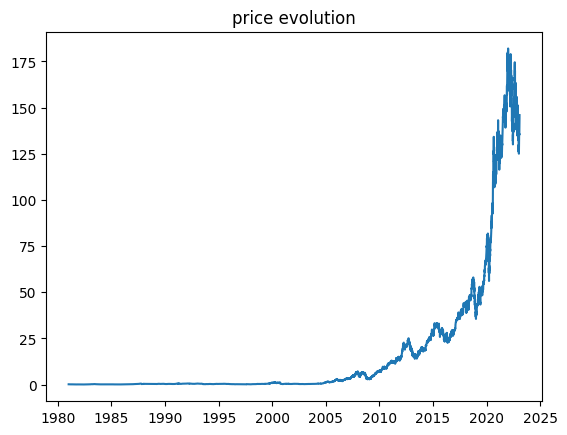

In [13]:
plt.plot(df['Date'], df['Close'])
plt.title("price evolution")
plt.show()

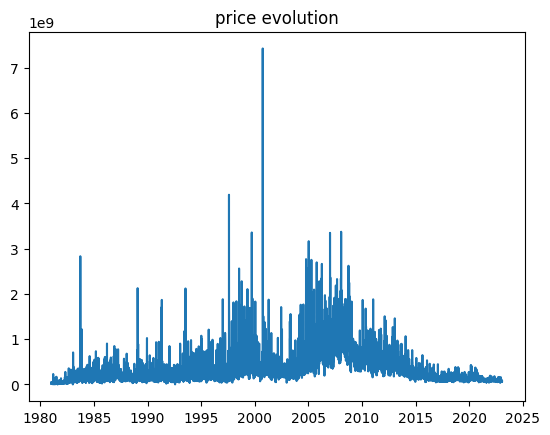

In [14]:
plt.plot(df['Date'], df['Volume'])
plt.title("price evolution")
plt.show()

/Users/mariekrammer/anaconda3/lib/python3.10/site-packages/mplfinance/_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


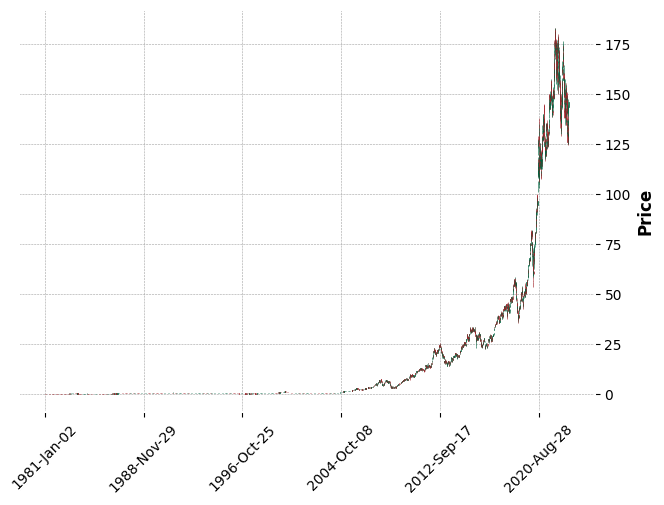

In [15]:
!pip install mplfinance
import mplfinance as mpf

df_copy = df.copy()
# Important : Date en index
df_copy = df_copy.set_index('Date')

mpf.plot(df_copy, type='candle', style='charles')

### Statistical Analysis

In [17]:
for col in df.columns[1:-1]:
    numpy_col = df[col].values
    print(f'Mean of {col}: {np.mean(numpy_col)}')
    print(f'Median of {col}: {np.median(numpy_col)}')
    print(f'Standard deviation of {col}: {np.std(numpy_col)}')
    print(f'Skewness of {col}: {stats.skew(numpy_col)}')
    print(f'Kurtosis of {col}: {stats.kurtosis(numpy_col)}')
    print(' ')

Mean of Open: 16.6891725885181
Median of Open: 0.488839
Standard deviation of Open: 35.44884791090304
Skewness of Open: 2.873315106810653
Kurtosis of Open: 7.776518750894095
 
Mean of High: 16.879955221342385
Median of High: 0.495536
Standard deviation of High: 35.8811564385601
Skewness of High: 2.8759647318257118
Kurtosis of High: 7.787010410583823
 
Mean of Low: 16.500821578525642
Median of Low: 0.4804465
Standard deviation of Low: 35.029637288417504
Skewness of Low: 2.870420947058953
Kurtosis of Low: 7.764808649334544
 
Mean of Close: 16.69736201451735
Median of Close: 0.487701
Standard deviation of Close: 35.47223956417653
Skewness of Close: 2.873265586829747
Kurtosis of Close: 7.77610495049443
 
Mean of Adj Close: 16.02734531806184
Median of Adj Close: 0.4048505
Standard deviation of Adj Close: 35.15322086006912
Skewness of Adj Close: 2.938345699117984
Kurtosis of Adj Close: 8.103706158483869
 
Mean of Volume: 327509817.26055807
Median of Volume: 214597600.0
Standard deviation of 

- columns Open, High, Low, Close and Adj Close: the median and the mean are very different, the median is way lower than the mean. the distribution is right skewed and there are a lot of outliers that pull the mean to the right.



- Volume : mean way higher than the median, the distribution is right skewed and outliers are very rare.

- range : the median and the mean are very different, the median is way lower than the mean. the distribution is right skewed and there are a lot of outliers that pull the mean to the right.

Let's analyze closing prices with a moving average.

In [18]:
df['MA10'] = df['Close'].rolling(window=10).mean() #smoothing the curve by taking average 10 days

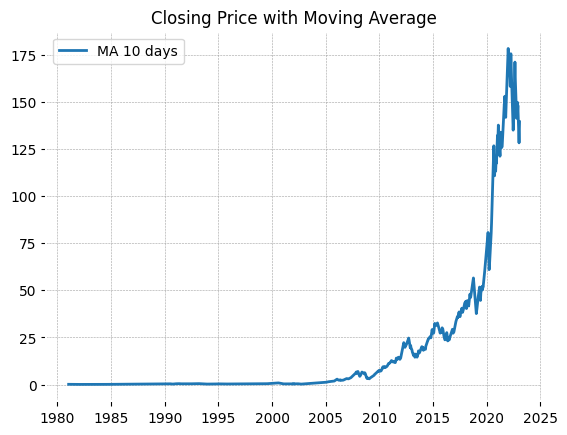

In [19]:
plt.plot(df['Date'], df['MA10'], label='MA 10 days')

plt.legend()
plt.title("Closing Price with Moving Average")
plt.show()

### Hypothesis Testing

Let's execute a t-test to compare average closing prices across different years.

H0: no differences between the years

In [32]:
df['Date'] = df['Date'].values
df['Year'] = df['Date'].dt.year
df_year = df.groupby('Year')['Close'].mean().reset_index()

groups = []

for year in df['Year'].unique():
    group = df[df['Year'] == year]['Close'].values
    groups.append(group)    

In [35]:
F_stat, p_value = stats.f_oneway(*groups)
print(f'F_stat = {F_stat}')
print(f'p_value = {p_value}')

F_stat = 12936.89834728488
p_value = 0.0


We reject the null hypothesis.

In [36]:
df['returns'] = df['Close'].pct_change()

/Users/mariekrammer/anaconda3/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


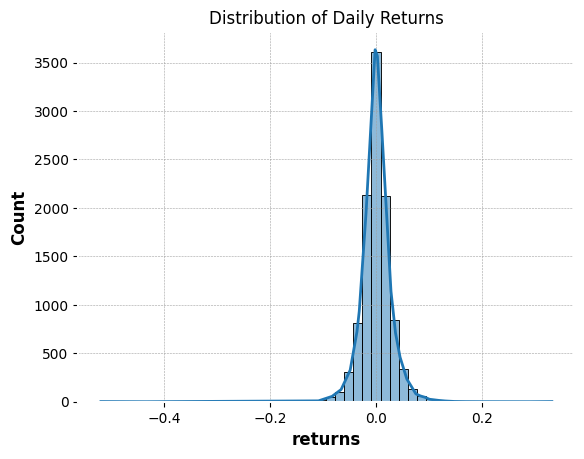

In [37]:
sns.histplot(df['returns'].dropna(), bins=50, kde=True)
plt.title("Distribution of Daily Returns")
plt.show()

In [38]:
stat, p_value = stats.normaltest(df['returns'].dropna())
print(stat, p_value)

2719.205287365936 0.0


### Summary and Insights

“The dataset is relatively clean, with no duplicates and no missing values. However, data for certain days are missing.

Apple’s stock price fluctuates, but overall it has increased significantly since 1980. It begins to rise more sharply around 2010, reaching a peak in 2022.

At the same time, the trading volume appears to stagnate and even decline.

There is a significant difference in the stock price across the years.”

### Reflection

Since the peak in 2022, the stock price appears to be declining, and intraday fluctuations have become quite significant. We should find solutions based on the previous pic. 